# 02 — Analyse par classes thérapeutiques et régions

**Objectif** : décrire la structure des remboursements de médicaments 2016–2025
selon deux axes :
- les **classes thérapeutiques** (ATC1) : lesquelles coûtent le plus, comment évoluent-elles ?
- les **régions** : quelles disparités de volume et de dynamique ?

**Note méthodologique** : les données sont agrégées **dès le chargement** en
(année × classe ATC1 × région), ce qui évite de garder ~18 millions de lignes en RAM.
Le résultat (~2 000 lignes) est exporté dans `data/clean/` pour être réutilisé
par les notebooks suivants.


## 0. Imports et chargement agrégé

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

# Palette Okabe-Ito (sûre pour le daltonisme), attribution fixe par classe
PALETTE = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7', '#56B4E9']

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CLEAN_DIR   = PROJECT_DIR / 'data' / 'clean'
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print('Projet :', PROJECT_DIR)
print('Clean  :', CLEAN_DIR)

Projet : C:\Users\Enes\projet_pharma
Clean  : C:\Users\Enes\projet_pharma\data\clean


In [2]:
def parse_euro(series):
    return (
        series.astype(str).str.strip()
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .replace('', '0').astype(float)
    )

# --- Harmonisation des libellés ATC1 -----------------------------------------
# Open Medic change de format d'année en année (accents, casse, troncature 2016,
# corruption d'encodage 2025) : sans harmonisation, une même classe thérapeutique
# apparaît sous 2 à 4 orthographes différentes et fausse tout groupby('l_atc1').
import unicodedata
import re

ATC1_CANONIQUES = [
    'Anti-infectieux (usage systémique)',
    'Antinéoplasiques et agents immunomodulants',
    'Antiparasitaires, insecticides et répulsifs',
    'Dermatologie',
    'Divers',
    'Hormones systémiques, à l exclusion des hormones sexuelles et des insulines',
    'Organes sensoriels',
    'Sang et organes hématopoiétiques',
    'Système cardio-vasculaire',
    'Système digestif et métabolisme',
    'Système génito-urinaire et hormones sexuelles',
    'Système musculo-squelettique',
    'Système nerveux',
    'Système respiratoire',
]
ATC1_ALIAS = {'SANG ET ORGANES HEMATOPOIETQUES': 'Sang et organes hématopoiétiques'}  # coquille source 2022-2024

def _normaliser_atc1_cle(serie):
    s = serie.astype(str).str.strip().str.upper()
    s = s.apply(lambda x: unicodedata.normalize('NFKD', x))
    s = s.str.encode('ascii', 'ignore').str.decode('ascii')
    return s.str.replace(r'[^A-Z0-9\x1a]+', ' ', regex=True).str.strip()

_cle_vers_canonique = {_normaliser_atc1_cle(pd.Series([c])).iloc[0]: c for c in ATC1_CANONIQUES}
_cles_canoniques = list(_cle_vers_canonique.keys())

def _resoudre_atc1(cle_brute):
    if cle_brute in _cle_vers_canonique:
        return _cle_vers_canonique[cle_brute]
    if '\x1a' in cle_brute:
        motif = re.compile('^' + re.escape(cle_brute).replace(re.escape('\x1a'), '.') + '$')
        matches = [c for c in _cles_canoniques if motif.match(c)]
        if len(matches) == 1:
            return _cle_vers_canonique[matches[0]]
    matches = [c for c in _cles_canoniques if c.startswith(cle_brute)]
    return _cle_vers_canonique[matches[0]] if len(matches) == 1 else None

def harmoniser_atc1(serie):
    """Ramène les libellés l_atc1 bruts (jusqu'à 45 variantes observées) aux 14
    vraies classes ATC1, quelle que soit l'année source."""
    brut = serie.astype(str).str.strip().replace(ATC1_ALIAS)
    return _normaliser_atc1_cle(brut).map(_resoudre_atc1).fillna(brut)

# --- Régions ------------------------------------------------------------------
# Note qualité données : le code ben_reg=5 est parfois documenté comme "Mayotte",
# mais son volume (~60M boîtes/an sur données complètes) est bien trop élevé pour
# ce territoire (300k hab.) et les codes 1-4 (Guadeloupe/Martinique/Guyane/Réunion)
# n'apparaissent jamais dans les données. Le code 5 regroupe très probablement les
# DOM/TOM agrégés — renommé en conséquence par prudence.
REG_LABELS = {
    1: 'Guadeloupe', 2: 'Martinique', 3: 'Guyane', 4: 'La Réunion',
    5: 'DOM/TOM (agrégés, code 5)',
    11: 'Île-de-France', 24: 'Centre-Val de Loire', 27: 'Bourgogne-Franche-Comté',
    28: 'Normandie', 32: 'Hauts-de-France', 44: 'Grand Est',
    52: 'Pays de la Loire', 53: 'Bretagne', 75: 'Nouvelle-Aquitaine',
    76: 'Occitanie', 84: 'Auvergne-Rhône-Alpes', 93: 'PACA', 94: 'Corse',
}

def load_year_agg(annee, data_dir):
    """Charge une année et la réduit immédiatement en (classe ATC1 × région)."""
    for pattern in [f'OPEN_MEDIC_{annee}.zip', f'OPEN_MEDIC_{annee}.csv']:
        path = data_dir / pattern
        if path.exists():
            break
    else:
        return None
    df = pd.read_csv(path, sep=None, engine='python', encoding='latin-1')
    df.columns = df.columns.str.lower().str.strip()
    if 'l_atc1' not in df.columns:
        return None
    df['rem'] = parse_euro(df['rem'])
    df['l_atc1'] = harmoniser_atc1(df['l_atc1'])
    agg = (
        df[df['l_atc1'].str.strip() != '']
        .groupby(['l_atc1', 'ben_reg'], as_index=False)
        .agg(rem=('rem', 'sum'), boites=('boites', 'sum'))
    )
    agg['annee'] = annee
    return agg

raw_dir  = PROJECT_DIR / 'data' / 'raw'
data_dir = raw_dir if any(raw_dir.glob('OPEN_MEDIC_*')) else Path('C:/Users/Enes/data')

frames = []
for annee in range(2016, 2026):
    agg = load_year_agg(annee, data_dir)
    if agg is not None:
        frames.append(agg)
        print(f'[{annee}] agrégé : {agg.shape[0]:,} lignes')

df = pd.concat(frames, ignore_index=True)
df['reg_label'] = df['ben_reg'].map(REG_LABELS)

premiere, derniere = int(df['annee'].min()), int(df['annee'].max())
print(f'\nTable finale : {df.shape[0]:,} lignes (année × classe × région), {premiere}–{derniere}')
print(f'Classes ATC1 harmonisées : {df["l_atc1"].nunique()}')

[2016] agrégé : 209 lignes


[2017] agrégé : 209 lignes


[2018] agrégé : 210 lignes


[2019] agrégé : 210 lignes


[2020] agrégé : 209 lignes


[2021] agrégé : 196 lignes


[2022] agrégé : 196 lignes


[2023] agrégé : 196 lignes


[2024] agrégé : 196 lignes


[2025] agrégé : 210 lignes

Table finale : 2,041 lignes (année × classe × région), 2016–2025
Classes ATC1 harmonisées : 14


---
## 1. Les classes thérapeutiques : qui coûte combien ?

Une classe peut coûter cher par le **volume** (beaucoup de boîtes bon marché)
ou par le **prix unitaire** (peu de boîtes très chères). Le coût moyen par boîte
permet de distinguer les deux profils.

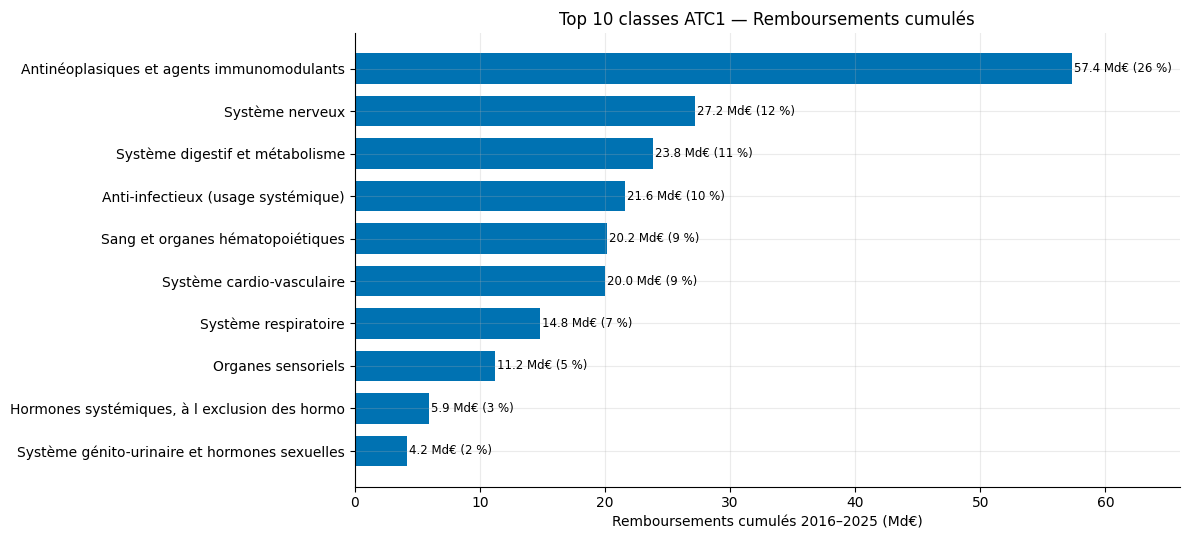

,rem_total,boites_total,cout_boite,part_pct
l_atc1,,,,
Antinéoplasiques et agents immunomodulants,"57,357,039,824 €","182,419,294",314.42 €,26.5 %
Système nerveux,"27,167,578,400 €","8,569,683,219",3.17 €,12.5 %
Système digestif et métabolisme,"23,817,373,929 €","3,972,462,422",6.00 €,11.0 %
Anti-infectieux (usage systémique),"21,596,362,666 €","1,506,557,811",14.33 €,10.0 %
Sang et organes hématopoiétiques,"20,161,490,278 €","1,256,277,131",16.05 €,9.3 %
Système cardio-vasculaire,"20,018,075,021 €","2,432,966,188",8.23 €,9.2 %
Système respiratoire,"14,834,620,065 €","1,465,723,785",10.12 €,6.8 %
Organes sensoriels,"11,211,532,762 €","783,344,264",14.31 €,5.2 %
"Hormones systémiques, à l exclusion des hormones sexuelles et des insulines","5,915,372,118 €","632,091,261",9.36 €,2.7 %


In [3]:
atc = (
    df.groupby('l_atc1')
    .agg(rem_total=('rem', 'sum'), boites_total=('boites', 'sum'))
    .sort_values('rem_total', ascending=False)
)
atc['cout_boite'] = (atc['rem_total'] / atc['boites_total']).round(2)
atc['part_pct']   = (atc['rem_total'] / atc['rem_total'].sum() * 100).round(1)

top10 = atc.head(10)

fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.barh([l[:45] for l in top10.index[::-1]], top10['rem_total'].iloc[::-1] / 1e9,
               color='#0072B2', height=0.72)
for bar, (val, pct) in zip(bars, zip(top10['rem_total'].iloc[::-1] / 1e9,
                                     top10['part_pct'].iloc[::-1])):
    ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f} Md€ ({pct:.0f} %)', va='center', fontsize=8.5)
ax.set_xlabel('Remboursements cumulés 2016–2025 (Md€)')
ax.set_title('Top 10 classes ATC1 — Remboursements cumulés')
ax.margins(x=0.15)
plt.tight_layout()
plt.show()

atc.head(14).style.format({'rem_total': '{:,.0f} €', 'boites_total': '{:,.0f}',
                           'cout_boite': '{:.2f} €', 'part_pct': '{:.1f} %'})

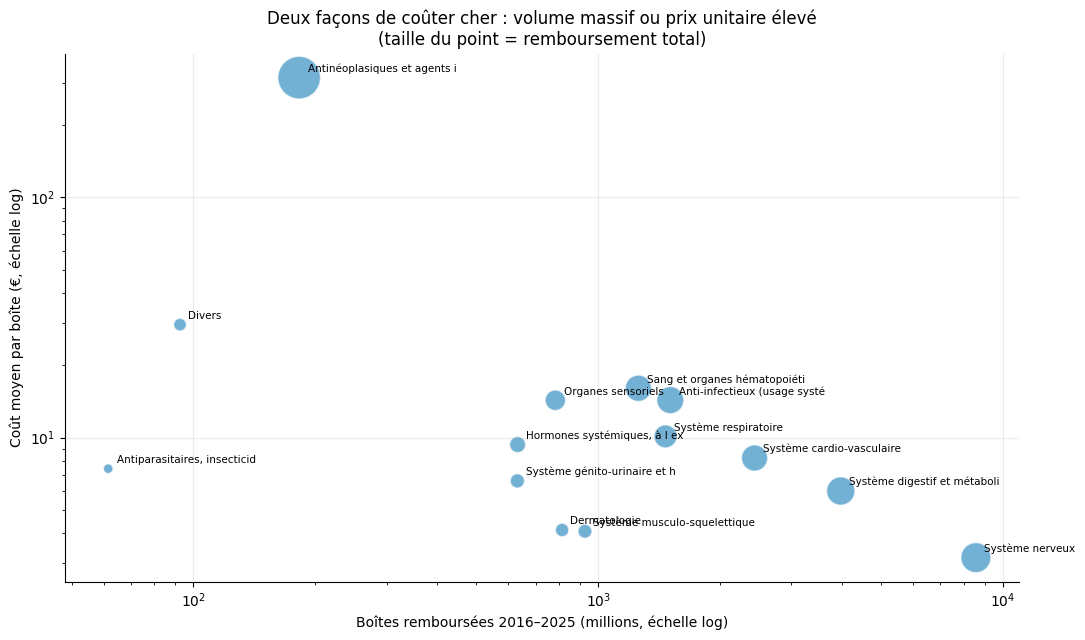

In [4]:
# Profil volume vs prix : chaque point est une classe ATC1
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(atc['boites_total'] / 1e6, atc['cout_boite'],
           s=atc['rem_total'] / atc['rem_total'].max() * 900 + 40,
           color='#0072B2', alpha=0.55, edgecolors='white', linewidths=1)
for label, row in atc.iterrows():
    ax.annotate(label[:28], (row['boites_total'] / 1e6, row['cout_boite']),
                fontsize=7.5, xytext=(6, 4), textcoords='offset points')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Boîtes remboursées 2016–2025 (millions, échelle log)')
ax.set_ylabel('Coût moyen par boîte (€, échelle log)')
ax.set_title('Deux façons de coûter cher : volume massif ou prix unitaire élevé\n(taille du point = remboursement total)')
plt.tight_layout()
plt.show()

### Évolution des principales classes

Attribution **fixe** des couleurs : chaque classe garde la sienne d'un graphique
à l'autre. Les classes hors top 6 sont regroupées dans « Autres classes ».

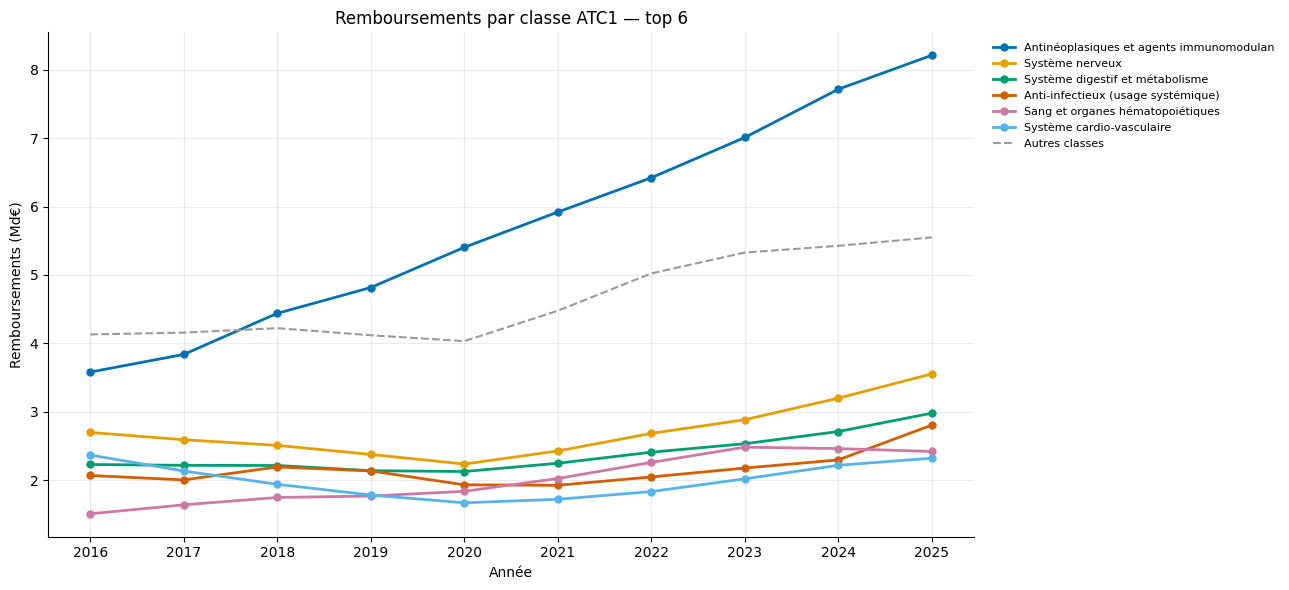

In [5]:
evo_atc = (
    df.groupby(['annee', 'l_atc1'])['rem'].sum()
    .unstack('l_atc1').fillna(0)
)
top6 = atc.head(6).index.tolist()
autres = evo_atc.drop(columns=top6).sum(axis=1)

fig, ax = plt.subplots(figsize=(13, 6))
for classe, couleur in zip(top6, PALETTE):
    ax.plot(evo_atc.index, evo_atc[classe] / 1e9, marker='o', markersize=5,
            linewidth=2, color=couleur, label=classe[:40])
ax.plot(autres.index, autres / 1e9, linewidth=1.5, linestyle='--',
        color='#999999', label='Autres classes')
ax.set_xticks(evo_atc.index)
ax.set_xlabel('Année')
ax.set_ylabel('Remboursements (Md€)')
ax.set_title('Remboursements par classe ATC1 — top 6')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

---
## 2. Les régions : volumes et dynamiques

**Attention à la lecture** : les volumes bruts reflètent d'abord la taille de la
population régionale. On regarde donc surtout le **coût moyen par boîte** et la
**dynamique** (variation sur la période), qui sont comparables entre régions.
Le code région 99 (inconnu / étranger) est exclu.

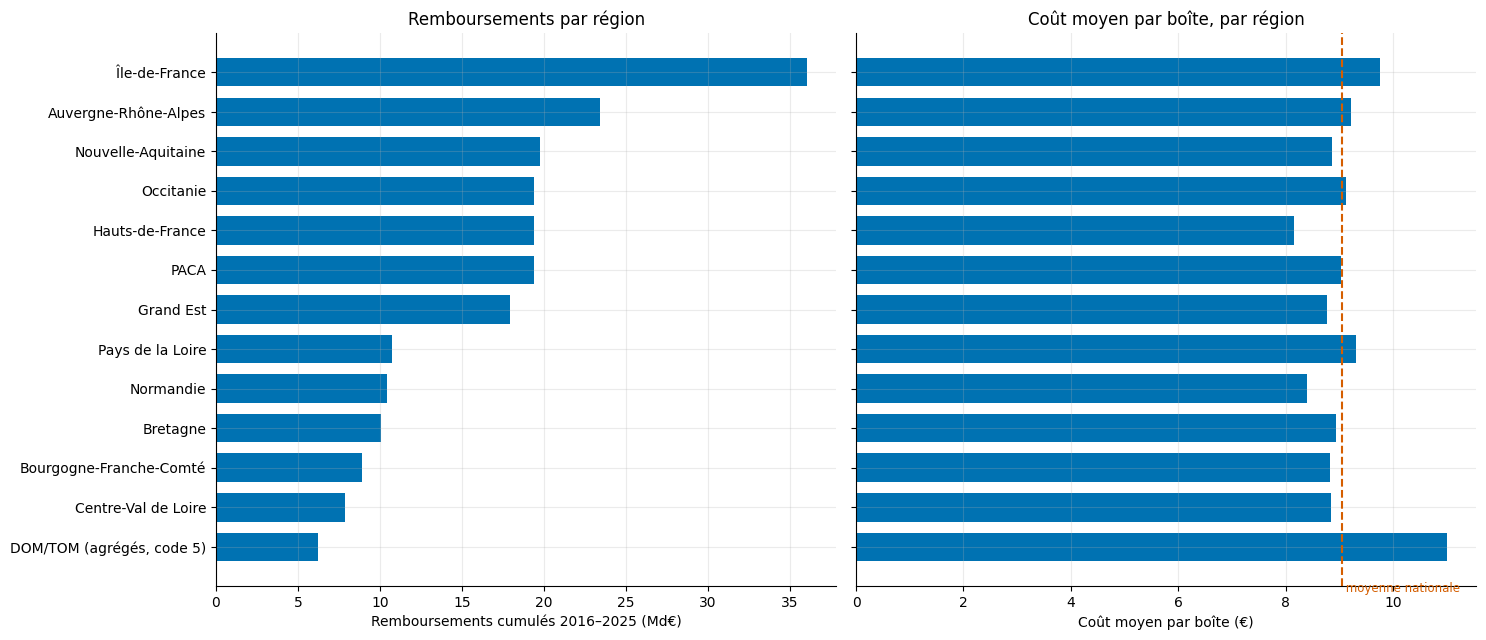

In [6]:
df_reg = df[df['ben_reg'] != 99]

reg = (
    df_reg.groupby('reg_label')
    .agg(rem_total=('rem', 'sum'), boites_total=('boites', 'sum'))
    .sort_values('rem_total', ascending=False)
)
reg['cout_boite'] = reg['rem_total'] / reg['boites_total']

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

axes[0].barh(reg.index[::-1], reg['rem_total'].iloc[::-1] / 1e9,
             color='#0072B2', height=0.72)
axes[0].set_xlabel('Remboursements cumulés 2016–2025 (Md€)')
axes[0].set_title('Remboursements par région')

axes[1].barh(reg.index[::-1], reg['cout_boite'].iloc[::-1],
             color='#0072B2', height=0.72)
axes[1].axvline(df_reg['rem'].sum() / df_reg['boites'].sum(),
                color='#D55E00', linewidth=1.5, linestyle='--')
axes[1].text(df_reg['rem'].sum() / df_reg['boites'].sum(), -0.9,
             ' moyenne nationale', color='#D55E00', fontsize=8.5, va='top')
axes[1].set_xlabel('Coût moyen par boîte (€)')
axes[1].set_title('Coût moyen par boîte, par région')
axes[1].set_yticklabels([])

plt.tight_layout()
plt.show()

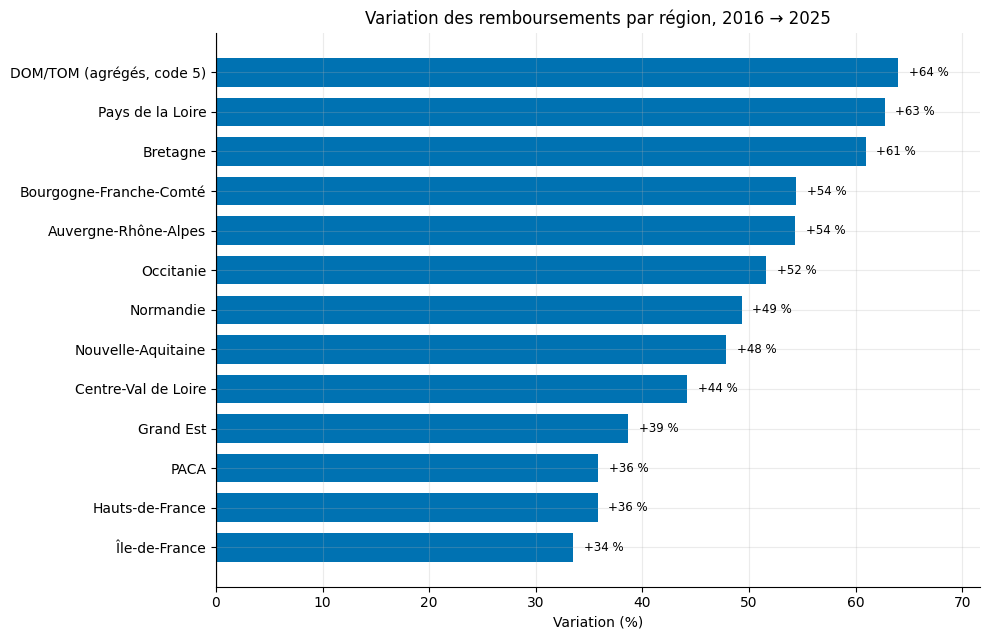

In [7]:
# Dynamique régionale : variation des remboursements entre première et dernière année
evo_reg = (
    df_reg.groupby(['annee', 'reg_label'])['rem'].sum()
    .unstack('annee').fillna(0)
)
variation = ((evo_reg[derniere] - evo_reg[premiere]) / evo_reg[premiere] * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 6.5))
couleurs = ['#D55E00' if v < 0 else '#0072B2' for v in variation]
bars = ax.barh(variation.index, variation, color=couleurs, height=0.72)
for bar, v in zip(bars, variation):
    ax.text(v + (1 if v >= 0 else -1), bar.get_y() + bar.get_height() / 2,
            f'{v:+.0f} %', va='center', ha='left' if v >= 0 else 'right', fontsize=8.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Variation (%)')
ax.set_title(f'Variation des remboursements par région, {premiere} → {derniere}')
ax.margins(x=0.12)
plt.tight_layout()
plt.show()

---
## 3. Croisement classe × région

Part de chaque classe ATC1 dans le total remboursé de sa région (les colonnes
somment à 100 %). Une teinte séquentielle unique encode la magnitude : plus
c'est foncé, plus la classe pèse dans la région.

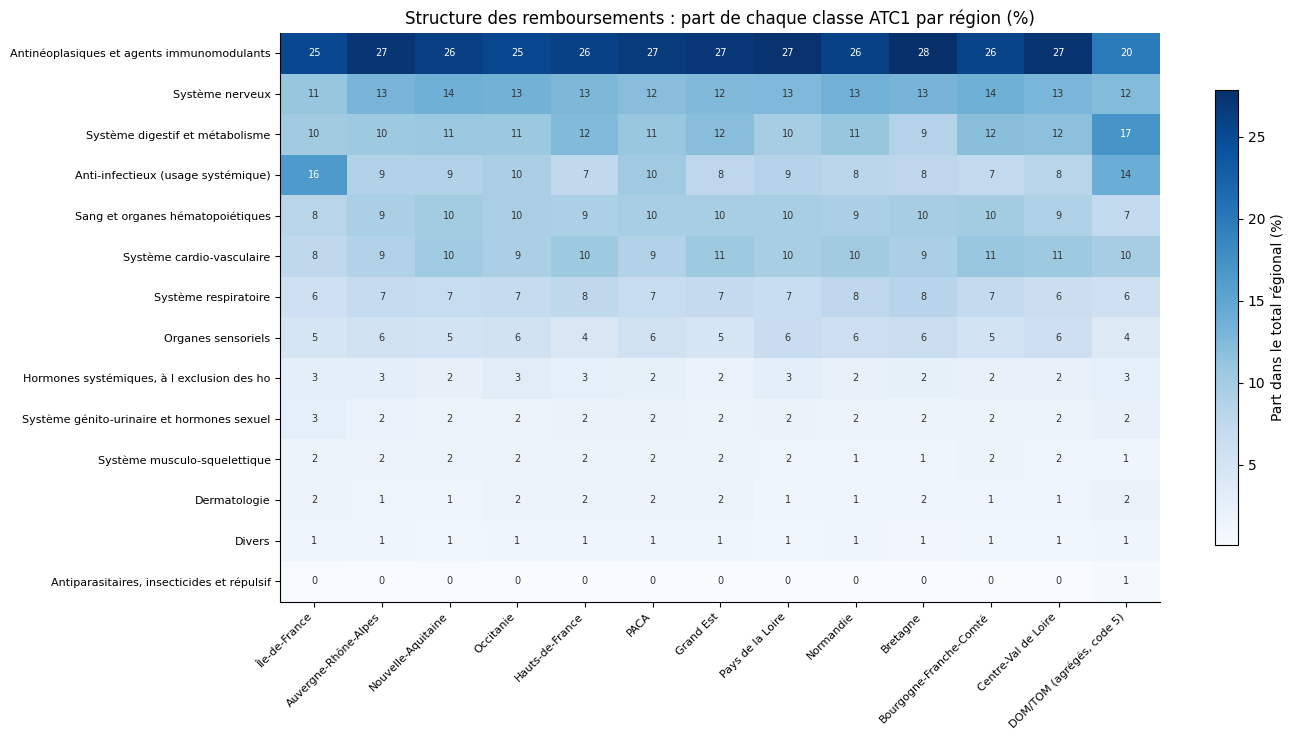

In [8]:
croise = (
    df_reg.groupby(['l_atc1', 'reg_label'])['rem'].sum()
    .unstack('reg_label').fillna(0)
)
croise_pct = croise / croise.sum() * 100
# Ordonne les lignes par poids national, les colonnes par total régional
croise_pct = croise_pct.loc[atc.index, reg.index]

fig, ax = plt.subplots(figsize=(14, 7.5))
im = ax.imshow(croise_pct.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(croise_pct.shape[1]))
ax.set_xticklabels(croise_pct.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(croise_pct.shape[0]))
ax.set_yticklabels([l[:42] for l in croise_pct.index], fontsize=8)
ax.grid(False)

seuil = croise_pct.values.max() * 0.55
for i in range(croise_pct.shape[0]):
    for j in range(croise_pct.shape[1]):
        v = croise_pct.values[i, j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=7,
                color='white' if v > seuil else '#333333')

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Part dans le total régional (%)')
ax.set_title('Structure des remboursements : part de chaque classe ATC1 par région (%)')
plt.tight_layout()
plt.show()

In [9]:
# Où chaque région s'écarte-t-elle le plus de la structure nationale ?
part_nationale = atc['part_pct']
ecarts = croise_pct.sub(part_nationale, axis=0)

ecart_max = ecarts.abs().max().sort_values(ascending=False).head(10)
print('Écart maximal à la structure nationale (points de %) :\n')
for region in ecart_max.index:
    classe = ecarts[region].abs().idxmax()
    v = ecarts.loc[classe, region]
    print(f'  {region:<28} {classe[:38]:<40} {v:+.1f} pts')

Écart maximal à la structure nationale (points de %) :

  DOM/TOM (agrégés, code 5)    Antinéoplasiques et agents immunomodul   -6.8 pts
  Île-de-France                Anti-infectieux (usage systémique)       +6.4 pts
  Bourgogne-Franche-Comté      Anti-infectieux (usage systémique)       -2.7 pts
  Hauts-de-France              Anti-infectieux (usage systémique)       -2.5 pts
  Bretagne                     Système digestif et métabolisme          -2.3 pts
  Grand Est                    Anti-infectieux (usage systémique)       -2.2 pts
  Normandie                    Anti-infectieux (usage systémique)       -2.0 pts
  Centre-Val de Loire          Anti-infectieux (usage systémique)       -1.8 pts
  Pays de la Loire             Anti-infectieux (usage systémique)       -1.5 pts
  Occitanie                    Antinéoplasiques et agents immunomodul   -1.2 pts


---
## 4. Synthèse et export

**Ce qu'il faut retenir :**
- Une poignée de classes ATC1 concentre l'essentiel des remboursements ;
  le scatter volume × prix distingue les classes « masse » (volume énorme,
  boîte bon marché) des classes « premium » (oncologie, immunologie).
- Les écarts régionaux de volume suivent d'abord la démographie ; le coût
  moyen par boîte et la dynamique de croissance sont plus discriminants.
- La structure par classe est remarquablement stable d'une région à l'autre,
  avec quelques spécificités locales (voir écarts ci-dessus).

La table agrégée est exportée pour les notebooks suivants (03, 05, 06) —
ils peuvent la recharger en une seconde au lieu de relire les fichiers bruts.

In [10]:
export_path = CLEAN_DIR / 'agg_annee_atc1_region.csv'
df.to_csv(export_path, index=False, encoding='utf-8')
print(f'Exporté : {export_path} ({df.shape[0]:,} lignes)')

Exporté : C:\Users\Enes\projet_pharma\data\clean\agg_annee_atc1_region.csv (2,041 lignes)
